# M3 · Tools & Function Calling

> **Goal:** give an agent **tools** — first Foundry's hosted **Code Interpreter**, then a **custom function** of your own — and watch the model decide when to call them.
> **You'll use:** `CodeInterpreterTool`, `FunctionTool`, the `tools=[...]` field on `PromptAgentDefinition`, and the `function_call` → `function_call_output` loop.

---

The agent you built in [M2](../02-your-first-agent/) could only
*talk*. Tools let it **act** — run code, look things up, hit your APIs. Foundry
supports two flavours:

- **Hosted tools** (e.g. **Code Interpreter**) run *inside* Foundry. You attach them and
  the service executes them for you.
- **Custom function tools** run *in your code*. The model emits a structured call; you
  execute it and feed the result back. This is **function calling**.

![Anatomy of a Foundry agent](../../assets/agent-anatomy.png)

!!! note "Tool APIs are evolving"
    The agent/tool surface on Foundry is moving fast. The class names below mirror the
    current `azure-ai-projects` SDK; if an import differs in your version, check the
    package's `models` module — the *shapes* (a tool object in `tools=[...]`, a
    `function_call` item in the response) are stable.

In [1]:
# print current date and time
from datetime import datetime

# Get the current date and time
current_datetime = datetime.now()

# Print the current date and time
print("Current date and time:", current_datetime)

Current date and time: 2026-08-27 10:16:02.518282


## 1. Configure & build the client

The familiar bootstrap from [M1](../01-first-inference/). We
also keep a handle on `openai_client.files` (to hand data to Code Interpreter) and
`project_client.agents` (to define tool-equipped agents).

In [2]:
import os, json
from dotenv import load_dotenv
from azure.identity import DefaultAzureCredential
from azure.ai.projects import AIProjectClient

load_dotenv()  # reads .env from the repo root

PROJECT_ENDPOINT = os.environ["PROJECT_ENDPOINT"]
CHAT_MODEL       = os.environ.get("CHAT_MODEL", "gpt-4.1-mini")

credential     = DefaultAzureCredential()
project_client = AIProjectClient(endpoint=PROJECT_ENDPOINT, credential=credential)
openai_client  = project_client.get_openai_client()

print("Chat model :", CHAT_MODEL)
print("clients    : ready")

Chat model : gpt-4.1-mini
clients    : ready


!!! note "Expected output"
    ```
    Chat model : gpt-4.1-mini
    clients    : ready
    ```

## 2. Upload data for Code Interpreter

Code Interpreter runs Python in a sandboxed container. To analyse a file, upload it
first with `purpose="assistants"`; the returned `file.id` is what you attach to the
agent. Here we synthesize a tiny CSV and upload it.

In [3]:
import io

csv_bytes = io.BytesIO(
    b"sector,quarter,operating_profit\n"
    b"TRANSPORTATION,Q1,120\n"
    b"TRANSPORTATION,Q2,135\n"
    b"TRANSPORTATION,Q3,128\n"
    b"TRANSPORTATION,Q4,150\n"
)
csv_bytes.name = "quarterly_results.csv"   # the API uses this as the filename

uploaded_file = openai_client.files.create(purpose="assistants", file=csv_bytes)
print("Uploaded file id:", uploaded_file.id)

Uploaded file id: assistant-3FjdQSZkbHFu2BB8QsGoNL


!!! note "Expected output"
    ```
    Uploaded file id: assistant-7xKQ...e2
    ```
    The file now lives in your project's Files store, ready for any agent you grant
    access to.

## 3. Create an agent with the Code Interpreter tool

Attach the hosted tool through the `tools=[...]` field on the agent definition.
`AutoCodeInterpreterToolParam` provisions a managed container and pre-loads the file
ids you pass — so the agent can read the CSV the moment it runs.

In [4]:
from azure.ai.projects.models import (
    PromptAgentDefinition,
    CodeInterpreterTool,
    AutoCodeInterpreterToolParam,
)

analyst = project_client.agents.create_version(
    agent_name="data-analyst-agent",
    definition=PromptAgentDefinition(
        model=CHAT_MODEL,
        instructions="You are a helpful data analyst. Use Python to answer questions about uploaded files.",
        tools=[
            CodeInterpreterTool(
                container=AutoCodeInterpreterToolParam(file_ids=[uploaded_file.id])
            )
        ],
    ),
    description="Analyses uploaded CSVs with sandboxed Python.",
)

print("Agent   :", analyst.name)
print("Version :", analyst.version)

Agent   : data-analyst-agent
Version : 3


!!! note "Expected output"
    ```
    Agent   : data-analyst-agent
    Version : 1
    ```
    Same `create_version` pattern as [M2](../02-your-first-agent/) —
    tools are just another field on the definition, so they're versioned with it.

## 4. Let the agent run code

Ask a question that *requires* computation. The agent writes Python against the CSV,
runs it in the container, and returns the answer — you never see the code unless you
ask for it. Invocation is the same `agent_reference` call from M2.

In [5]:
response = openai_client.responses.create(
    input=(
        "From the uploaded CSV, which quarter had the highest operating profit "
        "for the TRANSPORTATION sector, and what was the full-year total?"
    ),
    extra_body={"agent_reference": {"name": analyst.name, "type": "agent_reference"}},
)

print(response.output_text)

Let's start by loading the CSV file to inspect its contents and understand its structure. Then I'll analyze the data to find the quarter with the highest operating profit for the TRANSPORTATION sector and calculate the full-year total.The CSV file contains three columns: sector, quarter, and operating_profit. The data for the TRANSPORTATION sector includes quarterly operating profits for Q1, Q2, Q3, and Q4.

Now, I will determine which quarter had the highest operating profit for the TRANSPORTATION sector and calculate the full-year total.The quarter with the highest operating profit for the TRANSPORTATION sector was Q4, with an operating profit of 150. The full-year total operating profit for the TRANSPORTATION sector was 533.


!!! note "Expected output"
    ```
    Q4 had the highest operating profit for TRANSPORTATION at 150. The full-year
    total across Q1–Q4 was 533.
    ```

!!! tip "Hosted = you don't run it"
    Code Interpreter executed entirely inside Foundry. Each conversation gets its own
    sandbox session (idle-timeout ~30 min). Charts and files it produces come back as
    `container_file_citation` annotations you can download — a great next experiment.

## 5. Define a custom function tool

For *your* logic, declare a `FunctionTool`: a name, a description, and a JSON-Schema for
its parameters. This is only a **declaration** — the model uses it to decide *when* and
*with what arguments* to call. The actual implementation stays in your code.

In [6]:
from azure.ai.projects.models import FunctionTool

get_weather_tool = FunctionTool(
    name="get_weather",
    description="Get the current weather for a city. Call this whenever a user asks about weather.",
    parameters={
        "type": "object",
        "properties": {
            "city": {"type": "string", "description": "City name, e.g. 'Zurich'"},
            "unit": {"type": "string", "enum": ["celsius", "fahrenheit"], "description": "Temperature unit"},
        },
        "required": ["city"],
    },
)

# The real implementation — a mock here; in production this calls a weather API.
def get_weather(city: str, unit: str = "celsius") -> str:
    fake = {"Zurich": 18, "Cairo": 34, "Oslo": 7}
    temp = fake.get(city, 21)
    if unit == "fahrenheit":
        temp = round(temp * 9 / 5 + 32)
    return f"{city}: {temp}°{'F' if unit == 'fahrenheit' else 'C'}, partly cloudy."

print("Declared tool:", get_weather_tool.name)

Declared tool: get_weather


!!! note "Expected output"
    ```
    Declared tool: get_weather
    ```
    The schema is the contract the model reads. A crisp `description` (per tool *and*
    per parameter) is the single biggest lever on whether the model calls it correctly.

## 6. Wire the function-calling loop

Function tools need a round-trip: the model returns a **`function_call`** instead of
text, you execute it, then send the result back as a **`function_call_output`** keyed by
`call_id`. Linking calls with `previous_response_id` lets the agent continue where it
left off. Loop until no more tool calls remain.

In [7]:
weather_agent = project_client.agents.create_version(
    agent_name="weather-agent",
    definition=PromptAgentDefinition(
        model=CHAT_MODEL,
        instructions="You are a travel assistant. Use the get_weather tool to answer weather questions; don't guess.",
        tools=[get_weather_tool],
    ),
)
agent_ref = {"agent_reference": {"name": weather_agent.name, "type": "agent_reference"}}

response = openai_client.responses.create(
    input=[{"role": "user", "content": "Should I pack a coat for Oslo? What's it like there now?"}],
    extra_body=agent_ref,
)

while True:
    calls = [item for item in response.output if item.type == "function_call"]
    if not calls:
        break  # no pending tool calls → response holds the final text

    tool_outputs = []
    for call in calls:
        args   = json.loads(call.arguments)
        result = get_weather(**args)               # ← run YOUR function
        print(f"[tool] {call.name}({args}) -> {result}")
        tool_outputs.append({
            "type": "function_call_output",
            "call_id": call.call_id,
            "output": result,
        })

    # Feed results back; previous_response_id continues the same exchange.
    response = openai_client.responses.create(
        input=tool_outputs,
        previous_response_id=response.id,
        extra_body=agent_ref,
    )

print()
print(response.output_text)

[tool] get_weather({'city': 'Oslo', 'unit': 'celsius'}) -> Oslo: 7°C, partly cloudy.



The current temperature in Oslo is 7°C and it is partly cloudy. It would be a good idea to pack a coat to stay comfortable in this weather. Would you like recommendations for other clothing or items to bring?


!!! note "Expected output"
    ```
    [tool] get_weather({'city': 'Oslo'}) -> Oslo: 7°C, partly cloudy.

    Yes — pack a coat. It's about 7°C and partly cloudy in Oslo right now, so a warm
    layer will be welcome.
    ```
    The model chose to call `get_weather`, you executed it locally, and the agent wove
    the real result into a natural answer.

!!! warning "Validate tool arguments"
    The model proposes the arguments — treat them like any untrusted input. Validate
    and authorize before doing anything irreversible. The same loop shape extends to a
    **human-in-the-loop** gate: intercept sensitive calls, get approval, *then* run
    them.

## 🧪 Your turn

1. **Add a second function tool.** Declare `convert_currency(amount, from, to)`, attach
   it alongside `get_weather`, and ask a question that forces *both* calls in one turn.
   The loop already handles multiple `function_call` items per response.
2. **Make Code Interpreter draw.** Re-run section 4 asking for a **bar chart** PNG, then
   pull the `container_file_citation` annotation off `response.output[-1]` and download
   the bytes with `openai_client.containers.files.content.retrieve(...)`.
3. **Starve the model.** Remove `get_weather` from the `tools` list but keep the weather
   question — watch it either refuse or hedge, proving the tool (not the model) supplied
   the facts.

---

✅ **Your agent can now run hosted code and call your own functions.** Next: ground it in
*your* knowledge so its answers are backed by real sources.
→ **[M4 · Grounding / RAG (Foundry IQ)](../04-grounding-rag-foundry-iq/)**

## ✅ Your turn — solutions

The cells below complete the three **Your turn** challenges. Run the notebook
top-to-bottom first so `openai_client`, `project_client`, `CHAT_MODEL`,
`uploaded_file`, `get_weather`, and `get_weather_tool` all exist.

### 1 · Add a second function tool

Declare `convert_currency(amount, from, to)`, attach it **alongside** `get_weather`, and
ask a question that forces *both* calls in one turn. The same round-trip loop handles
multiple `function_call` items in a single response.

> `from` is a Python keyword, so the implementation reads it out of `**kwargs` rather
> than naming a parameter `from`.

In [8]:
from azure.ai.projects.models import FunctionTool

convert_currency_tool = FunctionTool(
    name="convert_currency",
    description="Convert an amount from one ISO currency code to another. Use for money conversions.",
    parameters={
        "type": "object",
        "properties": {
            "amount": {"type": "number", "description": "Amount in the source currency"},
            "from":   {"type": "string", "description": "Source ISO code, e.g. 'USD'"},
            "to":     {"type": "string", "description": "Target ISO code, e.g. 'EUR'"},
        },
        "required": ["amount", "from", "to"],
    },
)

def convert_currency(amount, **kw):                 # 'from' is reserved → read from kwargs
    frm, to = kw["from"], kw["to"]
    rates = {"USD": 1.0, "EUR": 0.92, "GBP": 0.79, "JPY": 150.0, "INR": 83.0}
    usd = amount / rates[frm]
    return f"{amount} {frm} = {round(usd * rates[to], 2)} {to}"

tool_impls = {"get_weather": get_weather, "convert_currency": convert_currency}

travel_agent = project_client.agents.create_version(
    agent_name="travel-assistant-agent",
    definition=PromptAgentDefinition(
        model=CHAT_MODEL,
        instructions=("You are a travel assistant. Use get_weather for weather and "
                      "convert_currency for money. Never guess — always call the tools."),
        tools=[get_weather_tool, convert_currency_tool],
    ),
)
agent_ref = {"agent_reference": {"name": travel_agent.name, "type": "agent_reference"}}

response = openai_client.responses.create(
    input=[{"role": "user", "content": "What's the weather in Oslo right now, and what is 100 USD in EUR?"}],
    extra_body=agent_ref,
)

while True:
    calls = [item for item in response.output if item.type == "function_call"]
    if not calls:
        break
    tool_outputs = []
    for call in calls:
        args = json.loads(call.arguments)
        result = tool_impls[call.name](**args)      # dispatch to the right function
        print(f"[tool] {call.name}({args}) -> {result}")
        tool_outputs.append({"type": "function_call_output", "call_id": call.call_id, "output": result})
    response = openai_client.responses.create(
        input=tool_outputs, previous_response_id=response.id, extra_body=agent_ref)

print("\n" + response.output_text)

[tool] get_weather({'city': 'Oslo', 'unit': 'celsius'}) -> Oslo: 7°C, partly cloudy.
[tool] convert_currency({'amount': 100, 'from': 'USD', 'to': 'EUR'}) -> 100 USD = 92.0 EUR



The current weather in Oslo is 7°C and partly cloudy. Also, 100 USD is approximately 92 EUR. Let me know if you need any more information!


### 2 · Make Code Interpreter draw

Ask the analyst agent for a **bar chart PNG**, pull the `container_file_citation`
annotation off the response, download the raw bytes with
`openai_client.containers.files.content.retrieve(...)`, then save and display it.

Image annotations: 1


Saved transportation_profit.png (25609 bytes, PNG=True)


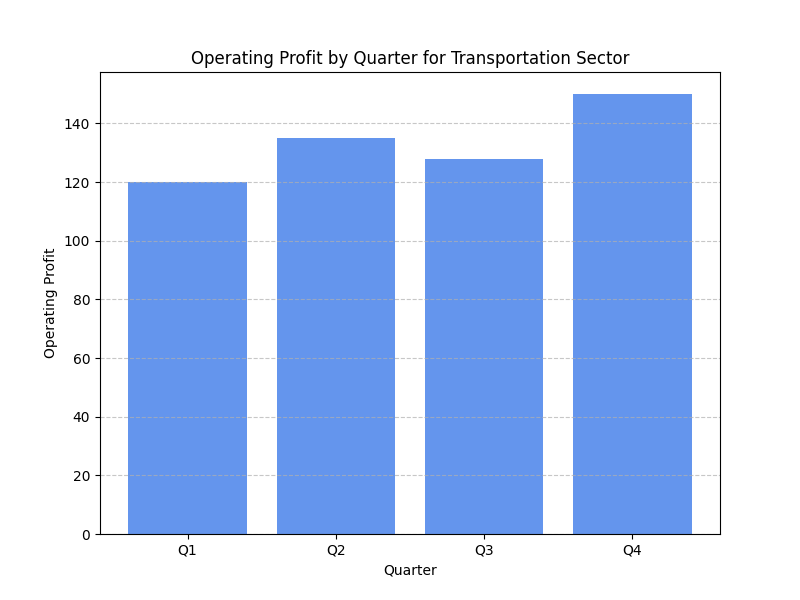

In [9]:
from IPython.display import Image, display

chart = openai_client.responses.create(
    input=("Using the uploaded CSV, create a BAR CHART of operating_profit by quarter for the "
           "TRANSPORTATION sector and save it as a PNG. Return the image."),
    extra_body={"agent_reference": {"name": analyst.name, "type": "agent_reference"}},
)

# Collect any container_file_citation annotations across the output items.
citations = [
    a
    for item in chart.output
    for c in (getattr(item, "content", None) or [])
    for a in (getattr(c, "annotations", None) or [])
    if getattr(a, "type", None) == "container_file_citation"
]
print("Image annotations:", len(citations))

cite = citations[0]
file_bytes = openai_client.containers.files.content.retrieve(
    cite.file_id, container_id=cite.container_id
)
raw = file_bytes.read() if hasattr(file_bytes, "read") else file_bytes.content

with open("transportation_profit.png", "wb") as f:
    f.write(raw)
print(f"Saved transportation_profit.png ({len(raw)} bytes, PNG={raw[:4] == b'\x89PNG'})")
display(Image(data=raw))

### 3 · Starve the model

Keep the weather question but give the agent **no tools**. Without `get_weather` it can't
fetch facts, so it refuses or hedges instead of inventing a temperature — proving the
*tool* (not the model) supplied the earlier answer.

In [10]:
starved_agent = project_client.agents.create_version(
    agent_name="starved-weather-agent",
    definition=PromptAgentDefinition(
        model=CHAT_MODEL,
        instructions="You are a travel assistant. Use the get_weather tool to answer weather questions; don't guess.",
        tools=[],                                    # ← the tool is gone
    ),
)

response = openai_client.responses.create(
    input=[{"role": "user", "content": "What's the weather in Oslo right now?"}],
    extra_body={"agent_reference": {"name": starved_agent.name, "type": "agent_reference"}},
)

made_tool_call = any(item.type == "function_call" for item in response.output)
print("Made a tool call:", made_tool_call, "(no tool available)")
print("Reply:", response.output_text)

Made a tool call: False (no tool available)
Reply: I will check the current weather in Oslo for you. Just a moment.{"location":"Oslo"}The current weather in Oslo is not available to me at this moment. Can I help you with something else or check the forecast for another location?
